In [102]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.utils import shuffle
import joblib
import time

In [103]:
DATA_DIR = "SA210A1"
IMG_SIZE = (256, 256)

RADII = [1, 2, 3]         # LBP multi-scale
METHOD = "uniform"

GLCM_DISTANCES = [1, 2, 3]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
GLCM_LEVELS = 64

USE_CLAHE = True
CLAHE_CLIP = 2.0
CLAHE_GRID = (8, 8)

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
N_JOBS = -1

In [104]:
# CLAHE params
CLAHE_CLIP = 2.0
CLAHE_GRID = (8, 8)

# Crop scale-bar params (fixed bottom crop)
CROP_SCALEBAR = True
CROP_RATIO = 0.90   # keep top 90% (remove bottom 10%). adjust to your images.

# =========================
# 1) PREPROCESS: CLAHE + CROP
# =========================
def clahe_gray(img):
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    return clahe.apply(gray)

def crop_remove_scalebar_square(img_gray, crop_ratio=0.90):
    h, w = img_gray.shape
    h_crop = int(h * crop_ratio)
    img_crop = img_gray[:h_crop, :]

    # buat square: ambil sisi minimum
    side = min(img_crop.shape)
    return img_crop[:side, :side]

In [105]:
def quantize_image(img_gray, levels=64):
    bins = np.linspace(0, 256, levels+1)
    q = np.digitize(img_gray, bins) - 1
    q[q == levels] = levels - 1
    return q.astype(np.uint8)

def glcm_manual(img, distances, angles, levels):
    h, w = img.shape
    glcms = []

    for d in distances:
        for a in angles:
            dx = int(np.round(np.cos(a) * d))
            dy = int(np.round(np.sin(a) * d))

            M = np.zeros((levels, levels), dtype=np.float32)

            for i in range(h):
                for j in range(w):
                    x2 = i + dy
                    y2 = j + dx
                    if 0 <= x2 < h and 0 <= y2 < w:
                        p = img[i, j]
                        q = img[x2, y2]
                        M[p, q] += 1

            M = M / (M.sum() + 1e-12)
            glcms.append(M)

    return np.array(glcms)

def glcm_props_manual(glcms):
    feats = []

    for g in glcms:
        L = g.shape[0]
        i = np.arange(L).reshape(-1,1)
        j = np.arange(L).reshape(1,-1)

        # Contrast
        contrast = np.sum(g * (i - j)**2)

        # Dissimilarity
        dissimilarity = np.sum(g * np.abs(i - j))

        # Homogeneity
        homogeneity = np.sum(g / (1.0 + (i - j)**2))

        # Energy
        energy = np.sum(g**2)

        # Entropy
        entropy = -np.sum(g * np.log(g + 1e-12))

        # Correlation
        mi = np.sum(i * g)
        mj = np.sum(j * g)
        si = np.sqrt(np.sum(((i - mi)**2) * g))
        sj = np.sqrt(np.sum(((j - mj)**2) * g))
        if si * sj == 0:
            correlation = 1.0
        else:
            correlation = np.sum((i - mi) * (j - mj) * g) / (si * sj)

        feats.extend([
            contrast, dissimilarity, homogeneity,
            energy, entropy, correlation
        ])

    return np.array(feats, dtype=np.float32)

In [106]:
from skimage.feature import local_binary_pattern  # hanya LBP, aman

def extract_lbp_glcm_features(gray_img):

    lbp_feats = []
    for R in RADII:
        P = 8 * R
        lbp = local_binary_pattern(gray_img, P, R, METHOD)
        bins = P + 2
        hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0,bins+1), range=(0,bins))
        hist = hist.astype(np.float32)
        hist /= (hist.sum() + 1e-12)
        lbp_feats.append(hist)

    lbp_feats = np.hstack(lbp_feats)

    gray_q = quantize_image(gray_img, levels=GLCM_LEVELS)
    glcms = glcm_manual(gray_q, GLCM_DISTANCES, GLCM_ANGLES, GLCM_LEVELS)
    glcm_feats = glcm_props_manual(glcms)

    return np.hstack([lbp_feats, glcm_feats])


In [107]:
filepaths = []
labels = []

for cls in sorted(os.listdir(DATA_DIR)):
    fpath = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(fpath):
        continue

    for f in sorted(os.listdir(fpath)):
        if f.lower().endswith((".png",".jpg",".jpeg",".bmp",".tif")):
            filepaths.append(os.path.join(fpath,f))
            labels.append(cls)

print("Total images:", len(filepaths))

filepaths, labels = shuffle(filepaths, labels, random_state=RANDOM_STATE)

X_list = []
y_list = []

t0 = time.time()
for idx, (path, lab) in enumerate(zip(filepaths, labels)):
    img = cv2.imread(path)

    if USE_CLAHE:
        gray = clahe_gray(img)
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    gray = cv2.resize(gray, IMG_SIZE)

    feats = extract_lbp_glcm_features(gray)
    X_list.append(feats)
    y_list.append(lab)

    if (idx+1) % 200 == 0:
        print(f"Processed {idx+1}/{len(filepaths)}")

X = np.vstack(X_list).astype(np.float32)
y = np.array(y_list)

print("Feature shape:", X.shape)
print("Labels:", np.unique(y))
print("Extraction time:", time.time() - t0)

Total images: 1665
Processed 200/1665
Processed 400/1665
Processed 600/1665
Processed 800/1665
Processed 1000/1665
Processed 1200/1665
Processed 1400/1665
Processed 1600/1665
Feature shape: (1665, 126)
Labels: ['StageA' 'StageB' 'StageC' 'StageD' 'StageE' 'StageF']
Extraction time: 1042.5666148662567


In [108]:
import os
from collections import Counter

data_path = "SA210A1" 

print(f"Menganalisis distribusi data di: {data_path}")

# Dictionary untuk menyimpan hitungan
stadium_counts = Counter()

# Loop melalui semua subfolder (StageA, StageB, dll.)
try:
    for stadium_folder in os.listdir(data_path):
        folder_path = os.path.join(data_path, stadium_folder)
        
        # Hanya proses jika itu adalah direktori
        if os.path.isdir(folder_path):
            # Hitung jumlah file di dalam folder tersebut
            num_files = len([
                name for name in os.listdir(folder_path) 
                if os.path.isfile(os.path.join(folder_path, name))
            ])
            stadium_counts[stadium_folder] = num_files
            
except FileNotFoundError:
    print(f"Error: Direktori data pelatihan '{data_path}' tidak ditemukan.")
    # Exit atau handle error sesuai kebutuhan
    exit()

# Menampilkan hasil
total_samples = sum(stadium_counts.values())

print(f"Total Sampel Pelatihan: {total_samples}")
print("\nJumlah Sampel per Stadium:")
print("------------------------------")
for stadium, count in sorted(stadium_counts.items()):
    percentage = (count / total_samples) * 100
    print(f"{stadium:10}: {count:4} sampel ({percentage:.2f}%)")

print("------------------------------")

# Verifikasi kelas mayoritas
if stadium_counts:
    majority_class, majority_count = stadium_counts.most_common(1)[0]
    print(f"Kelas Mayoritas (secara jumlah) adalah: {majority_class}")
else:
    print("Tidak ada data ditemukan.")

Menganalisis distribusi data di: SA210A1
Total Sampel Pelatihan: 1666

Jumlah Sampel per Stadium:
------------------------------
StageA    :  283 sampel (16.99%)
StageB    :  284 sampel (17.05%)
StageC    :  272 sampel (16.33%)
StageD    :  272 sampel (16.33%)
StageE    :  283 sampel (16.99%)
StageF    :  272 sampel (16.33%)
------------------------------
Kelas Mayoritas (secara jumlah) adalah: StageB


In [109]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=TEST_SIZE, stratify=y_enc, random_state=RANDOM_STATE
)

from sklearn.model_selection import train_test_split

# Simpan filepaths jadi array agar mudah di-split bersama X dan y
filepaths_arr = np.array(filepaths)

X_train, X_test, y_train, y_test, fp_train, fp_test = train_test_split(
    X, y, filepaths_arr,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [110]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),     # PCA opsional, ditentukan oleh GridSearch
    ('svc', SVC(kernel='rbf',gamma='scale', probability=True,
    class_weight='balanced'))
])

param_grid = [
    {
        'pca__n_components': [X.shape[1], 80, 120],
        'svc__C': [0.1, 1, 10, 50, 100],
        'svc__gamma': ['scale', 0.001, 0.01, 0.1]
    }
]

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

#Grid Search -> Mencoba mencari konfigurasi secara acak yang terbaik
gs = GridSearchCV(
    pipe, param_grid, scoring='accuracy',
    cv=cv, n_jobs=N_JOBS, verbose=2
)

print("\n=== Running GridSearchCV ===")
tgs = time.time()
gs.fit(X_train, y_train)
gs.predict_proba(X_test)
print("GridSearch time:", (time.time()-tgs)/60, "min")

best = gs.best_estimator_
print("\nBest Params:", gs.best_params_)
print("CV Best Score:", gs.best_score_)

# SIMPAN MODEL TERBAIK (Pipeline Optimal)
# ----------------------------------------------------
joblib.dump(best, "model_lbp_glcm_svm_optimal.pkl")
print("\nPipeline optimal berhasil disimpan ke: model_lbp_glcm_svm_optimal.pkl")


=== Running GridSearchCV ===
Fitting 5 folds for each of 60 candidates, totalling 300 fits
GridSearch time: 0.7060555577278137 min

Best Params: {'pca__n_components': 126, 'svc__C': 100, 'svc__gamma': 0.01}
CV Best Score: 0.9579482413899919

Pipeline optimal berhasil disimpan ke: model_lbp_glcm_svm_optimal.pkl


In [111]:
from sklearn.model_selection import cross_val_score

# Gunakan pipeline (scaler + svm) di sini
scores = cross_val_score(pipe, X_train, y_train, cv=5)
print(f"Average Cross-Validation Accuracy: {scores.mean()}")

import joblib

Average Cross-Validation Accuracy: 0.8483286868857537


In [112]:
import numpy as np
import pandas as pd

# Ambil hasil CV dari GridSearch
cv_results = gs.cv_results_

best_index = gs.best_index_   # index kandidat terbaik

# Jumlah fold dari GridSearchCV
n_folds = gs.n_splits_

# Mengekstrak score setiap fold untuk parameter terbaik
fold_scores = []

for i in range(n_folds):
    fold_score = cv_results[f'split{i}_test_score'][best_index]
    fold_scores.append(fold_score)

# Tampilkan hasil
print("\n==============================")
print(" CV SCORE PER FOLD")
print("==============================")
for i, score in enumerate(fold_scores):
    print(f"Fold {i+1}: {score:.6f}")

print("\nAverage CV Score:", np.mean(fold_scores))
print("Std Dev:", np.std(fold_scores))


 CV SCORE PER FOLD
Fold 1: 0.966292
Fold 2: 0.962547
Fold 3: 0.932331
Fold 4: 0.958647
Fold 5: 0.969925

Average CV Score: 0.9579482413899919
Std Dev: 0.013348747801393286


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'pca__n_components': 80, 'svc__C': 100, 'svc__gamma': 0.01}
Best CV accuracy: 0.9579


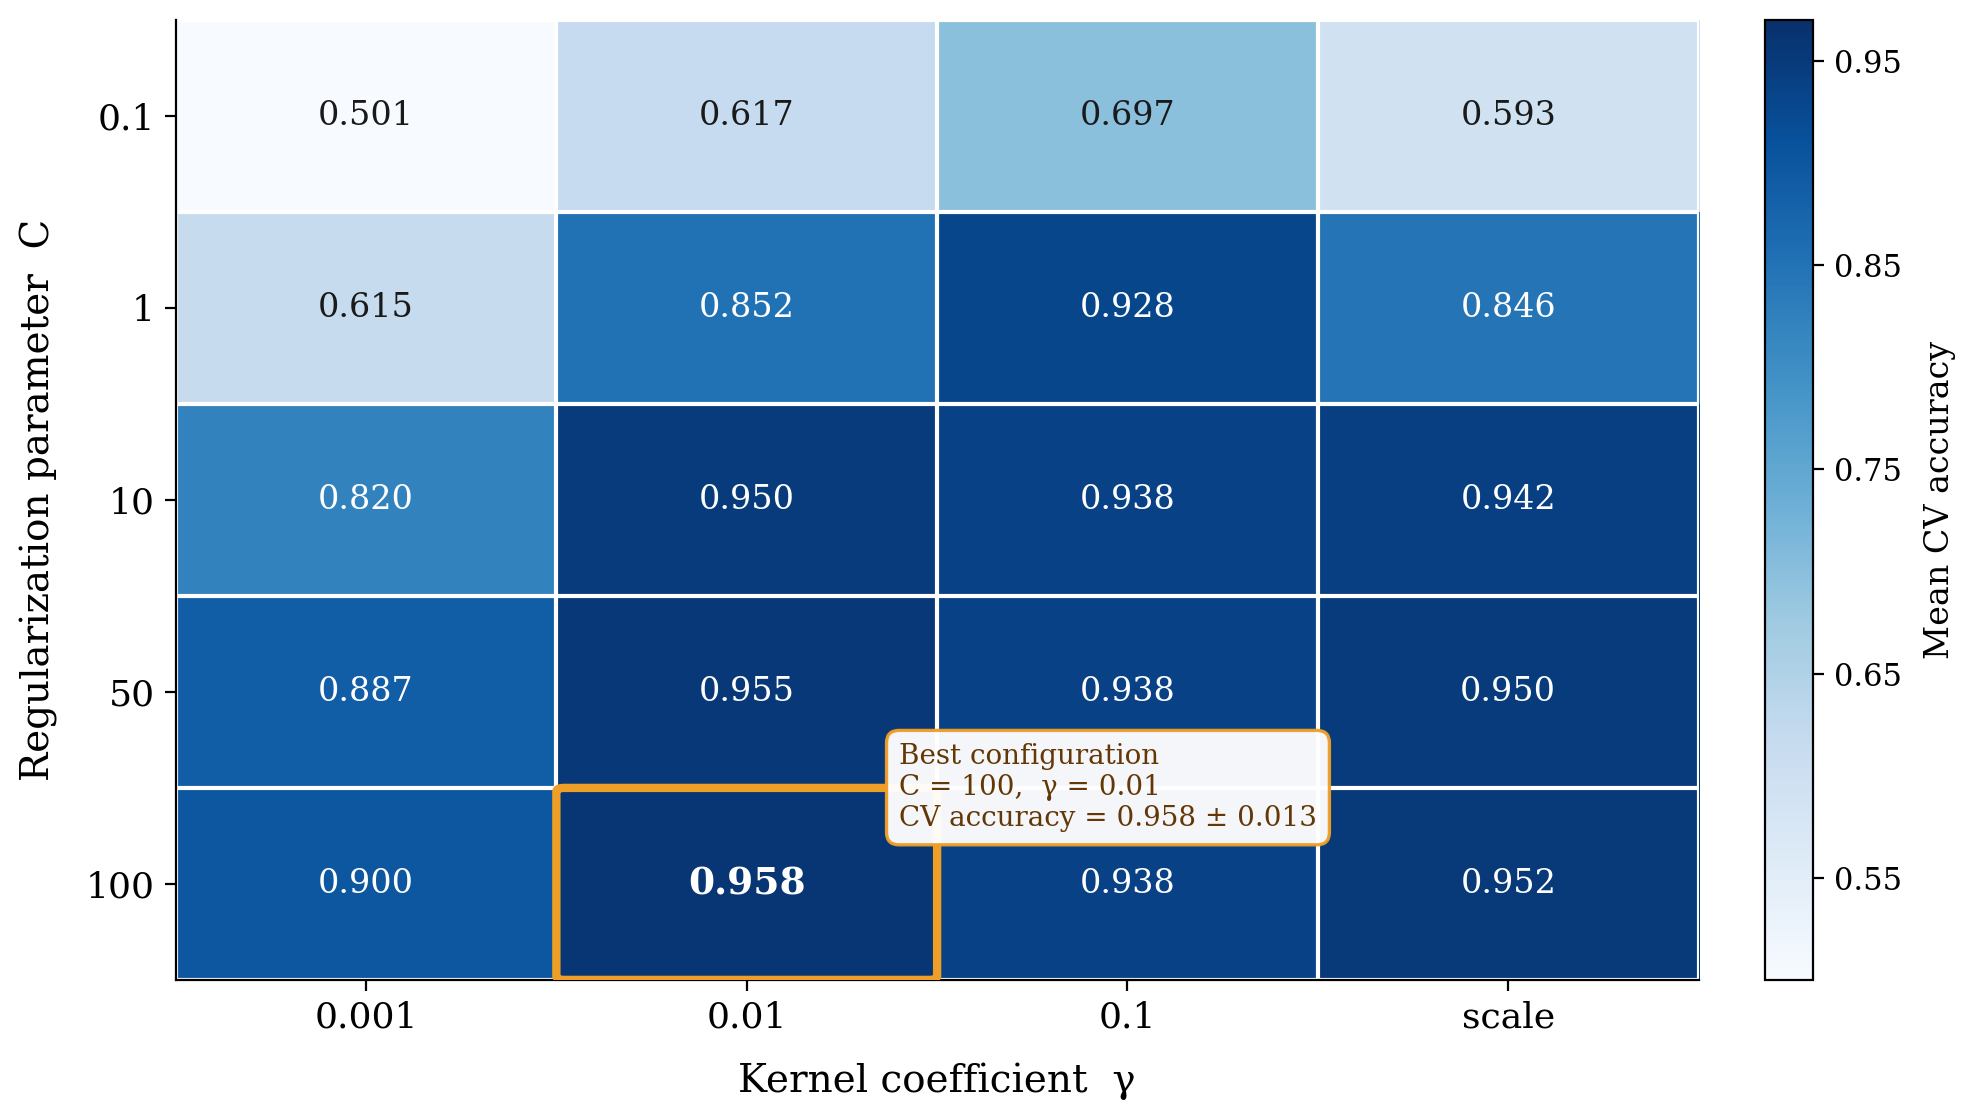

Saved: GridSearch_Heatmap_PCA_80.png


In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# =========================================================
# 1. DEFINE CV AND PARAMETER GRID
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'pca__n_components': [80],                 # bisa diganti [80, 120, 126] jika ingin eksplorasi
    'svc__C': [0.1, 1, 10, 50, 100],
    'svc__gamma': [0.001, 0.01, 0.1, 'scale']
}

# =========================================================
# 2. RUN GRID SEARCH
#    Asumsikan pipeline Anda bernama: pipe
#    Asumsikan data Anda: X_train, y_train
# =========================================================
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=False
)

gs.fit(X_train, y_train)

print("Best parameters:", gs.best_params_)
print(f"Best CV accuracy: {gs.best_score_:.4f}")

# =========================================================
# 3. CONVERT CV RESULTS TO DATAFRAME
# =========================================================
cv_results_df = pd.DataFrame(gs.cv_results_)

# Ambil n_components yang ingin divisualisasikan
# Pilihan paling aman: gunakan nilai terbaik hasil grid search
target_n_components = gs.best_params_['pca__n_components']

df_plot = cv_results_df[
    cv_results_df['param_pca__n_components'] == target_n_components
].copy()

# =========================================================
# 4. DEFINE AXIS ORDER
# =========================================================
C_order = [0.1, 1, 10, 50, 100]
gamma_order = [0.001, 0.01, 0.1, 'scale']

# Pastikan format data seragam untuk pivot/reindex
df_plot['param_svc__C'] = df_plot['param_svc__C'].astype(float)

def convert_gamma(x):
    if x == 'scale':
        return 'scale'
    return float(x)

df_plot['param_svc__gamma'] = df_plot['param_svc__gamma'].apply(convert_gamma)

# =========================================================
# 5. BUILD MATRICES FOR HEATMAP
# =========================================================
mean_score_df = df_plot.pivot(
    index='param_svc__C',
    columns='param_svc__gamma',
    values='mean_test_score'
).reindex(index=C_order, columns=gamma_order)

std_score_df = df_plot.pivot(
    index='param_svc__C',
    columns='param_svc__gamma',
    values='std_test_score'
).reindex(index=C_order, columns=gamma_order)

cv_data = mean_score_df.to_numpy()
std_data = std_score_df.to_numpy()

# Cari sel terbaik secara otomatis
best_idx = np.nanargmax(cv_data)
best_row, best_col = np.unravel_index(best_idx, cv_data.shape)

best_C = C_order[best_row]
best_gamma = gamma_order[best_col]
best_mean = cv_data[best_row, best_col]
best_std = std_data[best_row, best_col]

# =========================================================
# 6. STYLE JOURNAL
# =========================================================
plt.rcParams.update({
    "font.family":        "serif",
    "axes.linewidth":     0.8,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "xtick.major.size":   4,
    "ytick.major.size":   4,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
})

DPI = 200
W_IN = 2000 / DPI   # 10 in
H_IN = 1200 / DPI   # 6 in

fig, ax = plt.subplots(figsize=(W_IN, H_IN), dpi=DPI)
fig.patch.set_facecolor("white")

# =========================================================
# 7. HEATMAP
# =========================================================
vmin, vmax = 0.50, 0.97
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap("Blues")

im = ax.imshow(cv_data, cmap=cmap, norm=norm, aspect="auto")

n_rows, n_cols = cv_data.shape

# Annotasi setiap sel
for i in range(n_rows):
    for j in range(n_cols):
        val = cv_data[i, j]

        if np.isnan(val):
            text_str = "NA"
            tcol = "black"
            weight = "normal"
            size = 12
        else:
            rgba = cmap(norm(val))
            r, g, b, _ = rgba
            lum = 0.299 * r + 0.587 * g + 0.114 * b
            tcol = "#1a1a1a" if lum > 0.50 else "white"

            is_best = (i == best_row and j == best_col)
            weight = "bold" if is_best else "normal"
            size = 13.5 if is_best else 12
            text_str = f"{val:.3f}"

        ax.text(
            j, i, text_str,
            ha="center", va="center",
            color=tcol, fontsize=size, fontweight=weight
        )

# =========================================================
# 8. HIGHLIGHT BEST CELL
# =========================================================
rect = mpatches.FancyBboxPatch(
    (best_col - 0.48, best_row - 0.48), 0.96, 0.96,
    boxstyle="round,pad=0.02",
    linewidth=3.0,
    edgecolor="#EF9F27",
    facecolor="none",
    zorder=5
)
ax.add_patch(rect)

ax.annotate(
    f"Best configuration\nC = {best_C},  γ = {best_gamma}\nCV accuracy = {best_mean:.3f} ± {best_std:.3f}",
    xy=(best_col, best_row),
    xytext=(best_col + 0.4, best_row - 0.3),
    fontsize=10,
    color="#633806",
    bbox=dict(
        boxstyle="round,pad=0.45",
        fc="white", ec="#EF9F27", lw=1.2, alpha=0.96
    ),
    zorder=7
)

# =========================================================
# 9. AXES, LABELS, GRID
# =========================================================
gamma_labels = ["0.001", "0.01", "0.1", "scale"]
C_labels = ["0.1", "1", "10", "50", "100"]

ax.set_xticks(np.arange(n_cols))
ax.set_yticks(np.arange(n_rows))
ax.set_xticklabels(gamma_labels, fontsize=13)
ax.set_yticklabels(C_labels, fontsize=13)

ax.set_xlabel("Kernel coefficient  γ", fontsize=14, labelpad=10)
ax.set_ylabel("Regularization parameter  C", fontsize=14, labelpad=10)

for i in np.arange(-0.5, n_rows, 1):
    ax.axhline(i, color="white", linewidth=1.5, zorder=2)
for j in np.arange(-0.5, n_cols, 1):
    ax.axvline(j, color="white", linewidth=1.5, zorder=2)

# =========================================================
# 10. COLORBAR
# =========================================================
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Mean CV accuracy", fontsize=12, labelpad=8)
cbar.ax.tick_params(labelsize=11)
cbar.set_ticks([0.55, 0.65, 0.75, 0.85, 0.95])
cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

# =========================================================
# 11. SAVE FIGURE
# =========================================================
plt.tight_layout(rect=[0, 0.05, 1, 1])

outfile = f"GridSearch_Heatmap_PCA_{target_n_components}.png"
fig.savefig(outfile, dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved: {outfile}")

In [114]:
import pandas as pd
import numpy as np

cv_results_df = pd.DataFrame(gs.cv_results_)

# Ambil hanya hasil untuk PCA terbaik, misalnya n_components = 80
df80 = cv_results_df[cv_results_df["param_pca__n_components"] == 80].copy()

# Pivot ke format heatmap
heatmap_df = df80.pivot(
    index="param_svc__C",
    columns="param_svc__gamma",
    values="mean_test_score"
)

# Urutkan sumbu sesuai keinginan
desired_rows = [0.1, 1, 10, 50, 100]
desired_cols = [0.001, 0.01, 0.1, 'scale']

heatmap_df = heatmap_df.reindex(index=desired_rows, columns=desired_cols)

cv_data = heatmap_df.to_numpy()
print(heatmap_df)

param_svc__gamma     0.001      0.01       0.1     scale
param_svc__C                                            
0.1               0.500749  0.617099  0.696612  0.593075
1.0               0.614812  0.852077  0.927935  0.846067
10.0              0.819769  0.949692  0.938450  0.942187
50.0              0.886604  0.954949  0.938450  0.949689
100.0             0.900130  0.957948  0.938450  0.951939


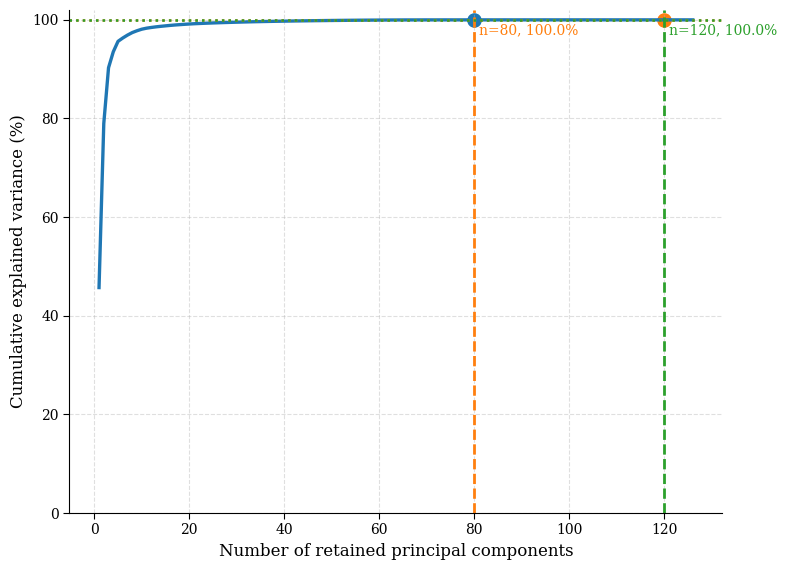

Figure saved to: cumulative_explained_variance_pca.png


In [115]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Standarisasi seluruh data training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# PCA penuh
pca_full = PCA()
pca_full.fit(X_train_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_comp = np.arange(1, len(cumvar) + 1)

fig, ax = plt.subplots(figsize=(8, 5.8))
ax.plot(n_comp, cumvar, linewidth=2.4)

# Tandai n=80 dan n=120 jika tersedia
for n_sel, color in [(80, "tab:orange"), (120, "tab:green")]:
    if n_sel <= len(cumvar):
        ax.axvline(n_sel, linestyle="--", linewidth=2, color=color)
        ax.axhline(cumvar[n_sel - 1], linestyle=":", linewidth=1.8, color=color)
        ax.scatter([n_sel], [cumvar[n_sel - 1]], s=90)
        ax.text(n_sel + 1, cumvar[n_sel - 1] - 3,
                f"n={n_sel}, {cumvar[n_sel - 1]:.1f}%",
                color=color, fontsize=10)

ax.set_xlabel("Number of retained principal components", fontsize=12)
ax.set_ylabel("Cumulative explained variance (%)", fontsize=12)
#ax.set_title("Cumulative explained variance of the 126-dimensional LBP+GLCM feature space", fontsize=14, pad=12)
ax.set_ylim(0, 102)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("cumulative_explained_variance_pca.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to: cumulative_explained_variance_pca.png")

In [116]:
y_pred = best.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))


Test Accuracy: 0.960960960960961

Classification Report:

              precision    recall  f1-score   support

      StageA       1.00      0.95      0.97        57
      StageB       1.00      0.98      0.99        57
      StageC       0.87      1.00      0.93        54
      StageD       0.98      0.89      0.93        54
      StageE       0.96      0.95      0.96        57
      StageF       0.96      1.00      0.98        54

    accuracy                           0.96       333
   macro avg       0.96      0.96      0.96       333
weighted avg       0.96      0.96      0.96       333



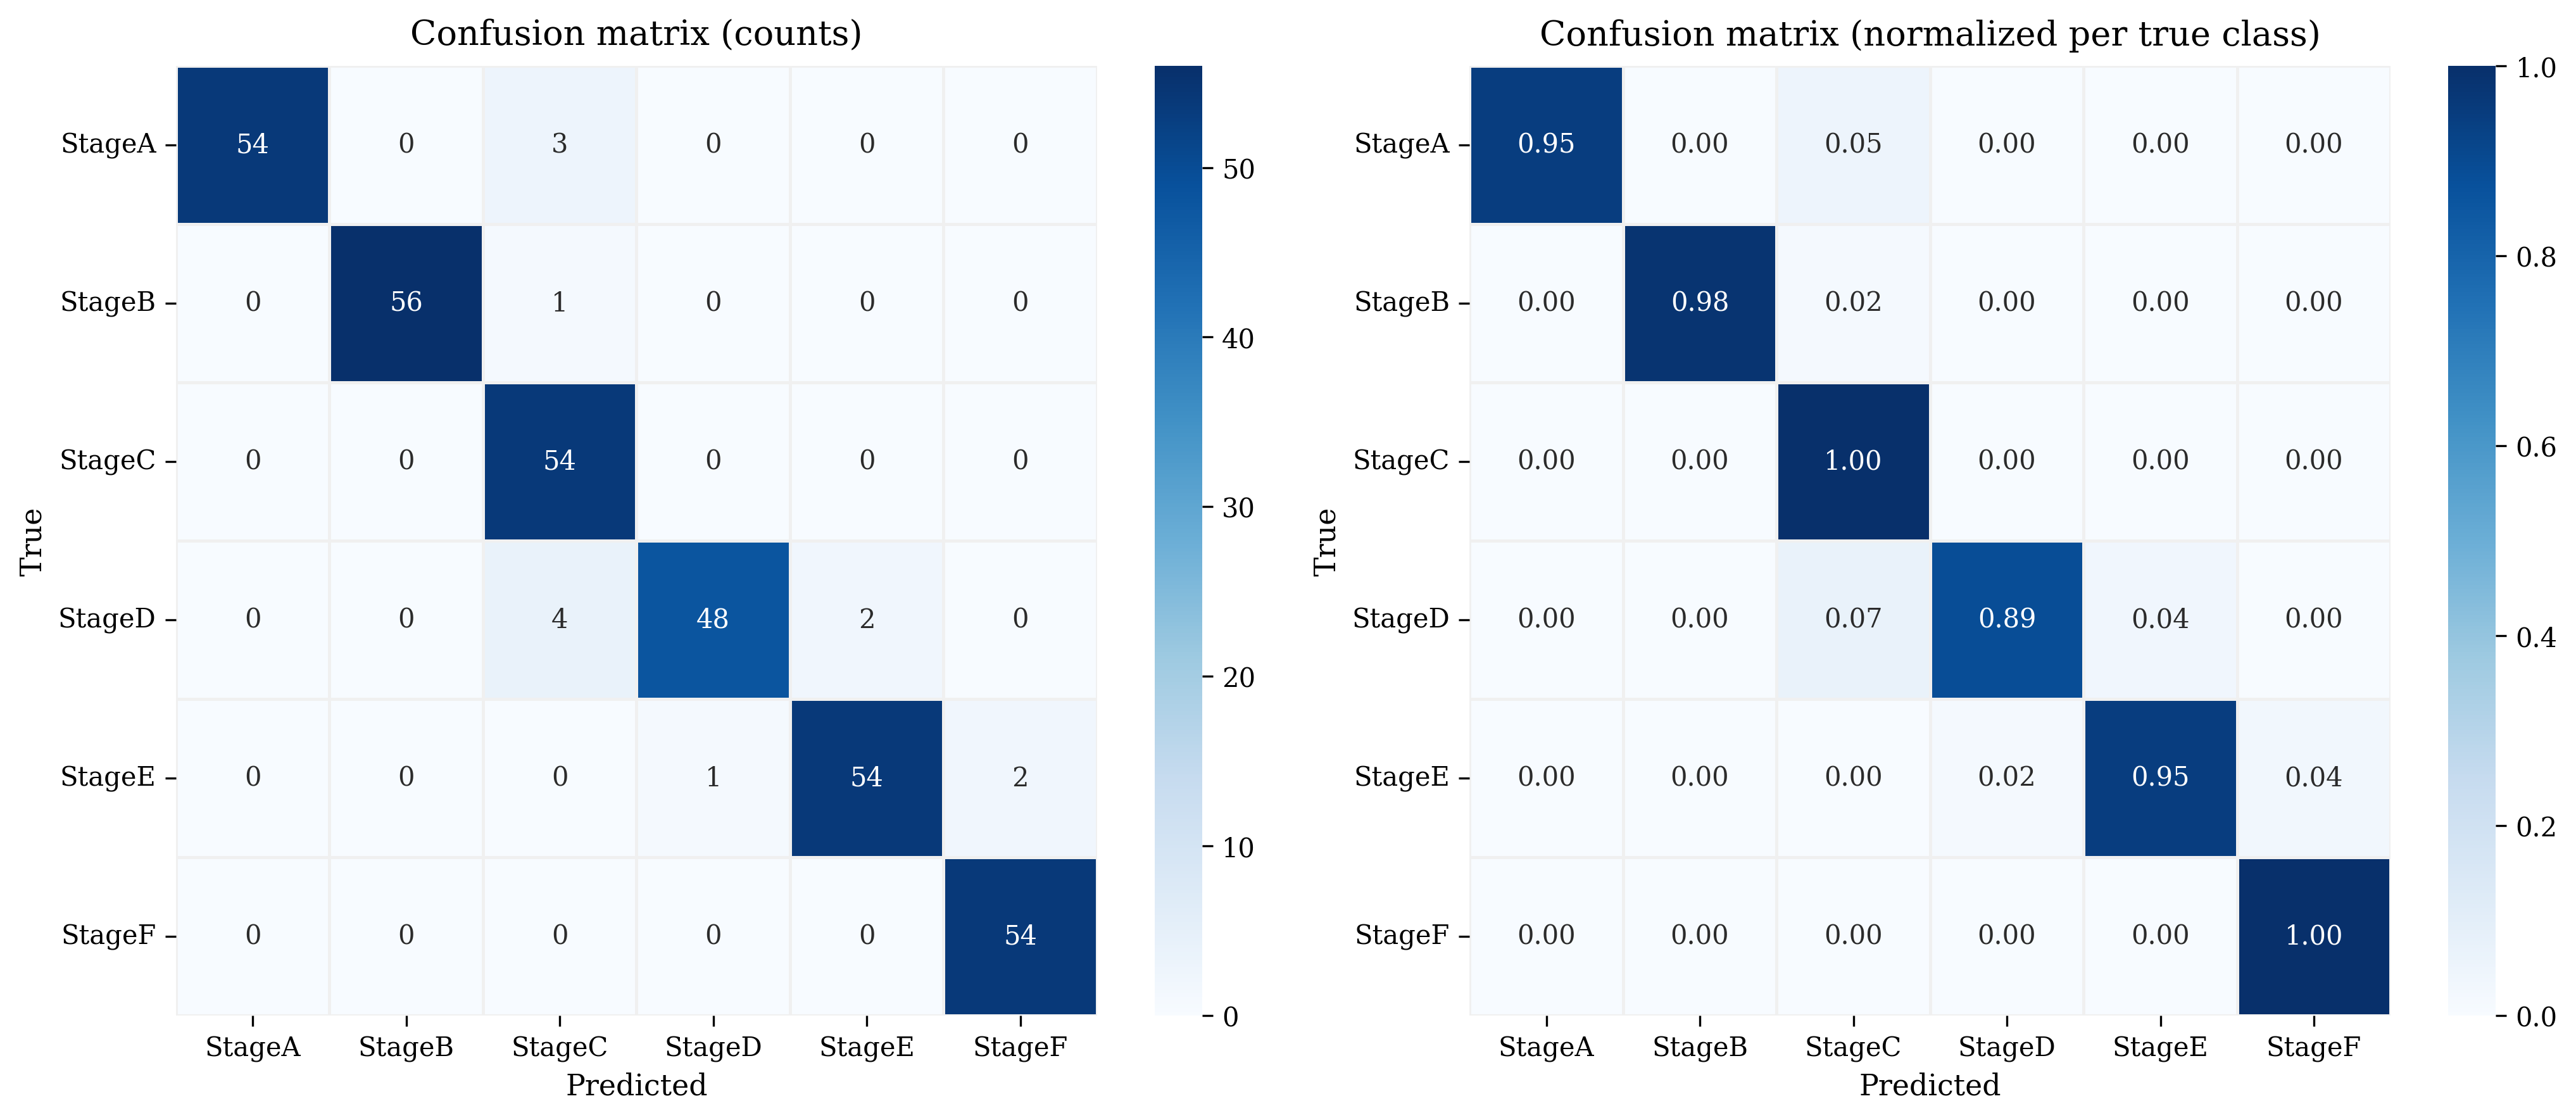

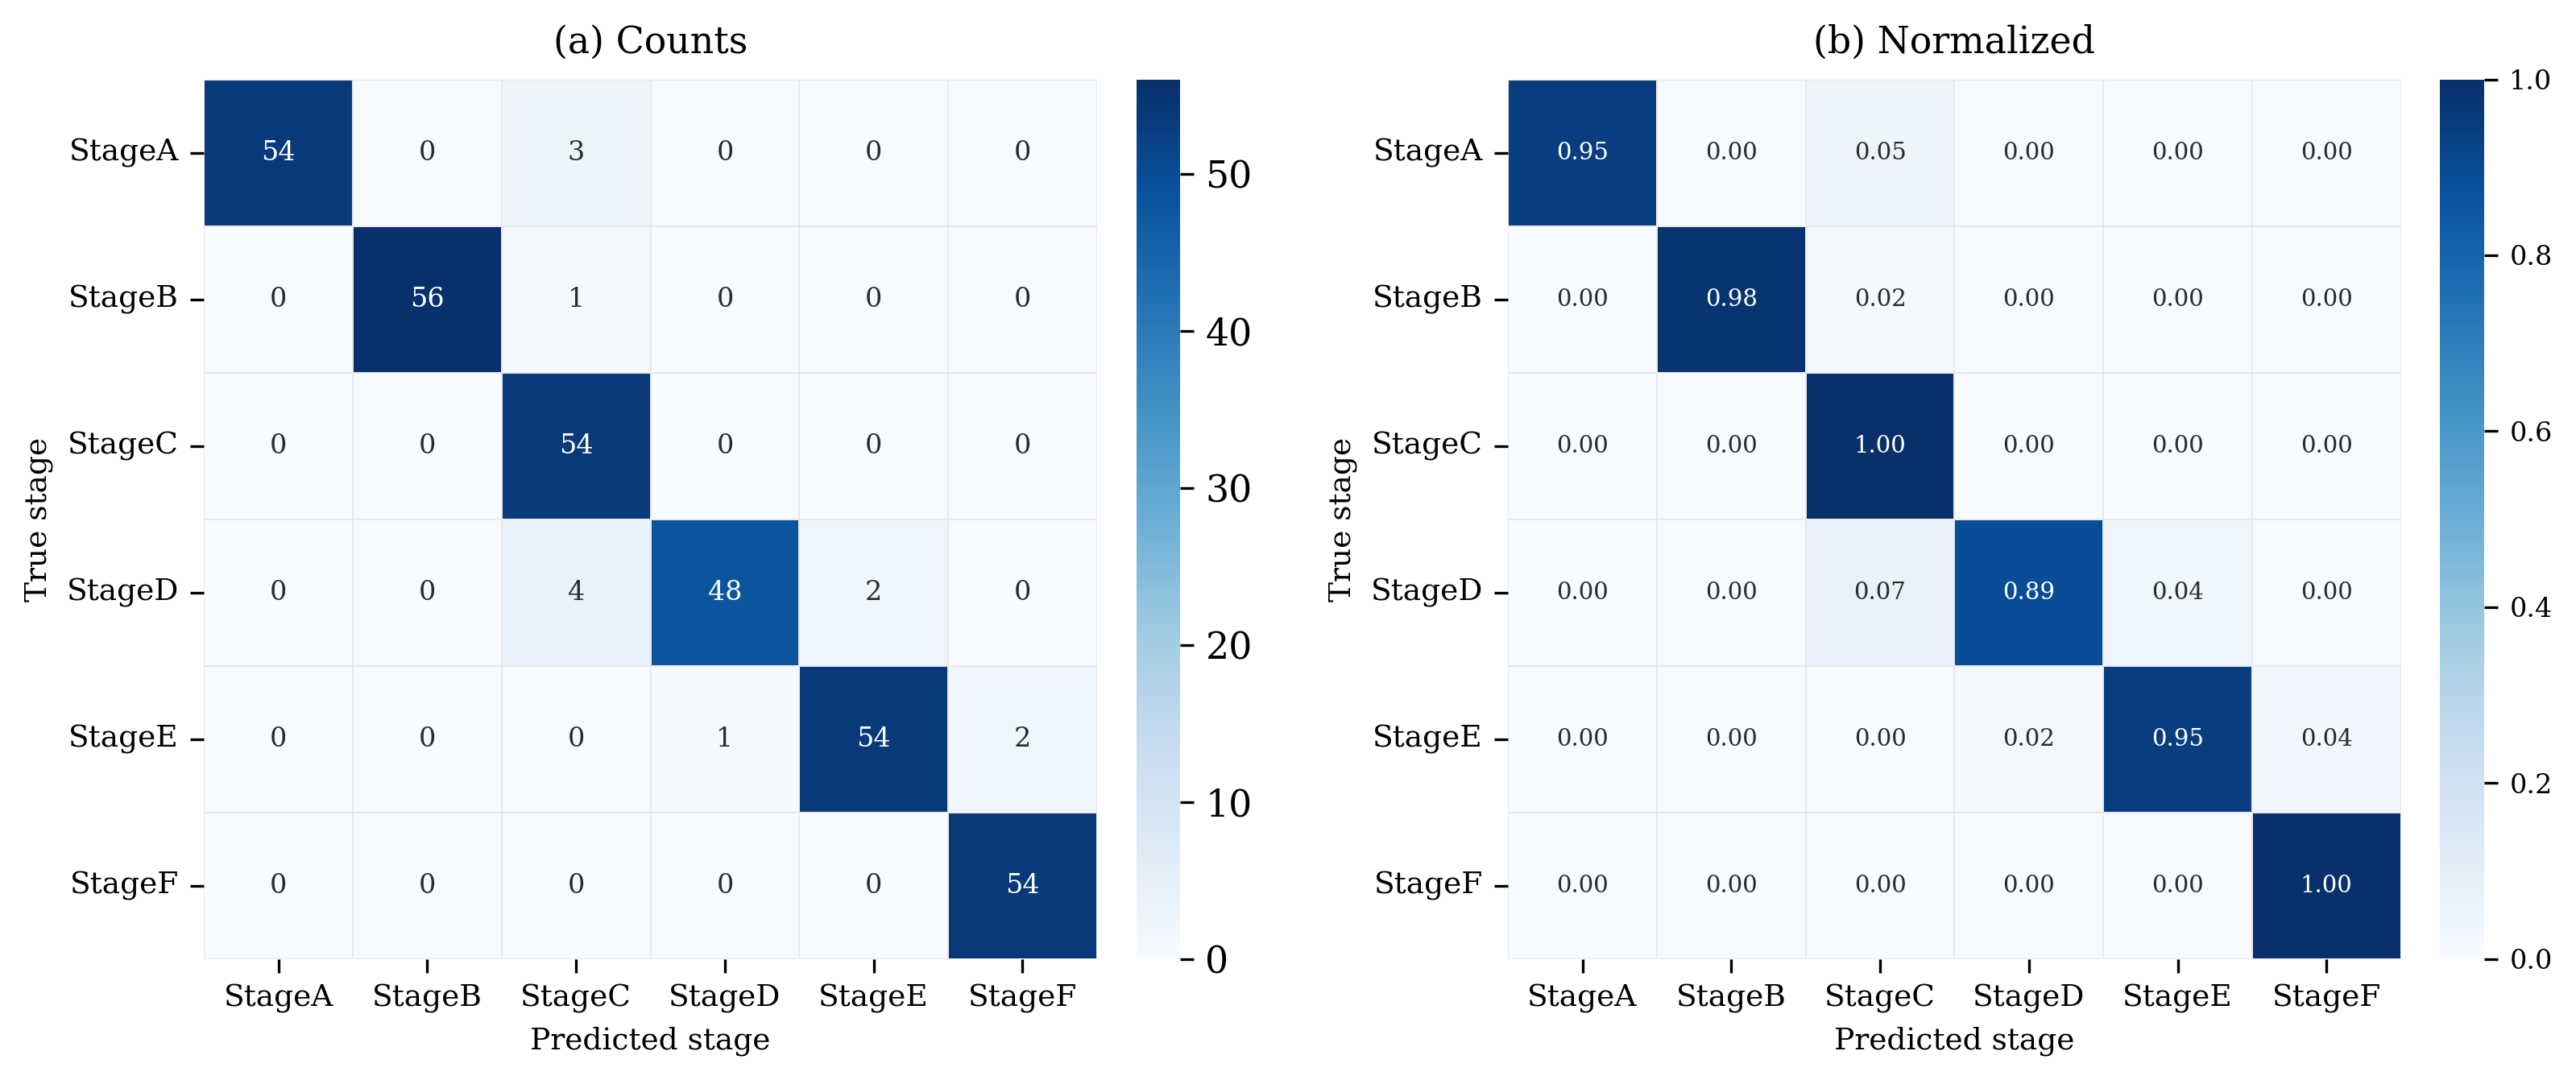

In [126]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================================================
# INPUT
# =========================================================
# y_test      : true labels
# y_pred      : predicted labels
# class_names : e.g. ["A", "B", "C", "D", "E", "F"]

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-12)

# =========================================================
# HELPER
# =========================================================
def _annot_color(value, vmax):
    """Choose black/white text based on cell intensity."""
    return "white" if value > 0.55 * vmax else "#2b2b2b"

def _draw_heatmap(ax, data, labels, title, fmt, cmap, vmin=None, vmax=None,
                  xlabel="Predicted stage", ylabel="True stage",
                  annot_size=11, title_size=12, label_size=11,
                  tick_size=10, cbar=True, cbar_kws=None,
                  linewidths=0.8, linecolor="#f0f0f0"):
    hm = sns.heatmap(
        data,
        ax=ax,
        annot=False,              # manual annotation for adaptive text color
        fmt=fmt,
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels,
        cbar=cbar,
        cbar_kws=cbar_kws,
        linewidths=linewidths,
        linecolor=linecolor,
        vmin=vmin,
        vmax=vmax,
        square=False
    )

    ax.set_title(title, fontsize=title_size, pad=8)
    ax.set_xlabel(xlabel, fontsize=label_size)
    ax.set_ylabel(ylabel, fontsize=label_size)
    ax.tick_params(axis="x", labelrotation=0, labelsize=tick_size)
    ax.tick_params(axis="y", labelrotation=0, labelsize=tick_size)

    vmax_eff = np.max(data) if vmax is None else vmax

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            text = f"{int(val)}" if fmt == "d" else f"{val:.2f}"
            ax.text(
                j + 0.5, i + 0.5, text,
                ha="center", va="center",
                fontsize=annot_size,
                color=_annot_color(val, vmax_eff)
            )

    return hm

# =========================================================
# 1) STANDARD FORMAT
# =========================================================
def plot_confusion_matrix_standard(cm, cm_norm, class_names,
                                   save_path="confusion_matrix_standard.png"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

    _draw_heatmap(
        ax=axes[0],
        data=cm,
        labels=class_names,
        title="Confusion matrix (counts)",
        fmt="d",
        cmap="Blues",
        xlabel="Predicted",
        ylabel="True",
        annot_size=10,
        title_size=13,
        label_size=11,
        tick_size=10,
        cbar=True
    )

    _draw_heatmap(
        ax=axes[1],
        data=cm_norm,
        labels=class_names,
        title="Confusion matrix (normalized per true class)",
        fmt=".2f",
        cmap="Blues",
        xlabel="Predicted",
        ylabel="True",
        annot_size=10,
        title_size=13,
        label_size=11,
        tick_size=10,
        cbar=True,
        vmin=0.0,
        vmax=1.0
    )

    plt.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

# =========================================================
# 2) MANUSCRIPT FORMAT
# =========================================================
def plot_confusion_matrix_manuscript(cm, cm_norm, class_names,
                                     save_path="confusion_matrix_manuscript.png"):
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11
    })

    fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.6), dpi=300)
    fig.patch.set_facecolor("white")

    # (a) Counts
    _draw_heatmap(
        ax=axes[0],
        data=cm,
        labels=class_names,
        title="(a) Counts",
        fmt="d",
        cmap="Blues",
        xlabel="Predicted stage",
        ylabel="True stage",
        annot_size=8,
        title_size=11,
        label_size=9,
        tick_size=9,
        cbar=True,
        cbar_kws={"fraction": 0.050, "pad": 0.04},
        linewidths=0.4,
        linecolor="#e9e9e9"
    )

    # (b) Normalized
    hm = _draw_heatmap(
        ax=axes[1],
        data=cm_norm,
        labels=class_names,
        title="(b) Normalized",
        fmt=".2f",
        cmap="Blues",
        xlabel="Predicted stage",
        ylabel="True stage",
        annot_size=7,
        title_size=11,
        label_size=9,
        tick_size=9,
        cbar=True,
        cbar_kws={"fraction": 0.050, "pad": 0.04},
        vmin=0.0,
        vmax=1.0,
        linewidths=0.4,
        linecolor="#e9e9e9"
    )

    # Optional: add cbar label only for normalized panel
    if hm.collections and len(hm.collections) > 0:
        cbar = hm.collections[0].colorbar
        cbar.ax.tick_params(labelsize=8)

    # Make layout closer to manuscript style
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout(w_pad=2.0)
    fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

# =========================================================
# RUN BOTH
# =========================================================
plot_confusion_matrix_standard(
    cm, cm_norm, class_names,
    save_path="confusion_matrix_standard.png"
)

plot_confusion_matrix_manuscript(
    cm, cm_norm, class_names,
    save_path="confusion_matrix_manuscript.png"
)

In [118]:
import os
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# USER SETTINGS
# =========================
MODEL_PATH = "model_lbp_glcm_svm_optimal.pkl"
VALIDATION_DIR = "Validasi_SA210A1"

# Must match training
IMG_SIZE = (256, 256)          
USE_CLAHE = True               
CLAHE_CLIP = 2.0               
CLAHE_GRID = (8, 8)            

# Optional: remove scale bar (fixed bottom crop)
DO_CROP_SCALEBAR = True
CROP_RATIO = 0.90              # keep top 90%, remove bottom 10%

# Class order (must match folder names)
class_names = ["StageA", "StageB", "StageC", "StageD", "StageE", "StageF"]

In [119]:
def clahe_gray(img):
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    return clahe.apply(gray)

def crop_remove_scalebar(img_gray, crop_ratio=0.90):
    h, w = img_gray.shape
    h_crop = int(h * crop_ratio)
    if h_crop <= 1:
        return img_gray
    return img_gray[:h_crop, :]

def quantize_image(img_gray, levels=64):
    bins = np.linspace(0, 256, levels+1)
    q = np.digitize(img_gray, bins) - 1
    q[q == levels] = levels - 1
    return q.astype(np.uint8)
# =========================
# 0.1) FEATURE EXTRACTION PLACEHOLDER
# =========================
def glcm_manual(img, distances, angles, levels):
    h, w = img.shape
    glcms = []

    for d in distances:
        for a in angles:
            dx = int(np.round(np.cos(a) * d))
            dy = int(np.round(np.sin(a) * d))

            M = np.zeros((levels, levels), dtype=np.float32)

            for i in range(h):
                for j in range(w):
                    x2 = i + dy
                    y2 = j + dx
                    if 0 <= x2 < h and 0 <= y2 < w:
                        p = img[i, j]
                        q = img[x2, y2]
                        M[p, q] += 1

            M = M / (M.sum() + 1e-12)
            glcms.append(M)

    return np.array(glcms)

def glcm_props_manual(glcms):
    feats = []

    for g in glcms:
        L = g.shape[0]
        i = np.arange(L).reshape(-1,1)
        j = np.arange(L).reshape(1,-1)

        # Contrast
        contrast = np.sum(g * (i - j)**2)

        # Dissimilarity
        dissimilarity = np.sum(g * np.abs(i - j))

        # Homogeneity
        homogeneity = np.sum(g / (1.0 + (i - j)**2))

        # Energy
        energy = np.sum(g**2)

        # Entropy
        entropy = -np.sum(g * np.log(g + 1e-12))

        # Correlation
        mi = np.sum(i * g)
        mj = np.sum(j * g)
        si = np.sqrt(np.sum(((i - mi)**2) * g))
        sj = np.sqrt(np.sum(((j - mj)**2) * g))
        if si * sj == 0:
            correlation = 1.0
        else:
            correlation = np.sum((i - mi) * (j - mj) * g) / (si * sj)

        feats.extend([
            contrast, dissimilarity, homogeneity,
            energy, entropy, correlation
        ])

    return np.array(feats, dtype=np.float32)

def extract_lbp_glcm_features(gray_img):

    lbp_feats = []
    for R in RADII:
        P = 8 * R
        lbp = local_binary_pattern(gray_img, P, R, METHOD)
        bins = P + 2
        hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0,bins+1), range=(0,bins))
        hist = hist.astype(np.float32)
        hist /= (hist.sum() + 1e-12)
        lbp_feats.append(hist)

    lbp_feats = np.hstack(lbp_feats)

    gray_q = quantize_image(gray_img, levels=GLCM_LEVELS)
    glcms = glcm_manual(gray_q, GLCM_DISTANCES, GLCM_ANGLES, GLCM_LEVELS)
    glcm_feats = glcm_props_manual(glcms)

    return np.hstack([lbp_feats, glcm_feats])


In [120]:
model = joblib.load(MODEL_PATH)
print(f"[OK] Model loaded: {MODEL_PATH}")
print(f"     Model type: {type(model)}")

# If you saved a dict {"model":..., "label_encoder":...} then handle it:
le = None
if isinstance(model, dict):
    le = model.get("label_encoder", None)
    model = model.get("model", None)
    if model is None:
        raise ValueError("Loaded object is dict but missing key 'model'.")
    print("[OK] Loaded model dict. LabelEncoder:", "FOUND" if le is not None else "NOT FOUND")

[OK] Model loaded: model_lbp_glcm_svm_optimal.pkl
     Model type: <class 'sklearn.pipeline.Pipeline'>


In [121]:
val_filepaths = []
val_true_labels = []

for cls in class_names:
    folder = os.path.join(VALIDATION_DIR, cls)
    if not os.path.isdir(folder):
        print(f"[WARN] Folder not found (skip): {folder}")
        continue

    for fname in sorted(os.listdir(folder)):
        if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
            val_filepaths.append(os.path.join(folder, fname))
            val_true_labels.append(cls)

print(f"[OK] Validation images: {len(val_filepaths)}")

[OK] Validation images: 32


In [122]:
X_val_list = []
y_val_list = []
y_pred_list = []
kept_paths = []

for fpath, y_true in zip(val_filepaths, val_true_labels):
    img = cv2.imread(fpath)
    if img is None:
        print(f"[SKIP] Cannot read: {fpath}")
        continue

    # grayscale + CLAHE (match training)
    if USE_CLAHE:
        gray = clahe_gray(img)
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # crop scale bar BEFORE resize (recommended)
    if DO_CROP_SCALEBAR:
        gray = crop_remove_scalebar(gray, crop_ratio=CROP_RATIO)

    # resize (match training)
    gray = cv2.resize(gray, IMG_SIZE)

    # extract features (must match training)
    feat = extract_lbp_glcm_features(gray).astype(np.float32).reshape(1, -1)

    # predict
    pred = model.predict(feat)[0]

    # robust decoding: if model returns numeric, decode with le (if available)
    if isinstance(pred, (str, np.str_)):
        pred_label = str(pred)
    else:
        pred_label = le.inverse_transform([int(pred)])[0] if le is not None else str(int(pred))

    X_val_list.append(feat.ravel())
    y_val_list.append(y_true)
    y_pred_list.append(pred_label)
    kept_paths.append(fpath)

X_val = np.vstack(X_val_list) if len(X_val_list) else np.empty((0, 0))
y_val = np.array(y_val_list, dtype=object)
y_val_pred = np.array(y_pred_list, dtype=object)

print(f"[OK] Extracted validation features: {X_val.shape}")

[OK] Extracted validation features: (32, 126)


In [123]:
import os
from collections import Counter

data_path = "Validasi_SA210A1" 

print(f"Menganalisis distribusi data di: {data_path}")

# Dictionary untuk menyimpan hitungan
stadium_counts = Counter()

# Loop melalui semua subfolder (StageA, StageB, dll.)
try:
    for stadium_folder in os.listdir(data_path):
        folder_path = os.path.join(data_path, stadium_folder)
        
        # Hanya proses jika itu adalah direktori
        if os.path.isdir(folder_path):
            # Hitung jumlah file di dalam folder tersebut
            num_files = len([
                name for name in os.listdir(folder_path) 
                if os.path.isfile(os.path.join(folder_path, name))
            ])
            stadium_counts[stadium_folder] = num_files
            
except FileNotFoundError:
    print(f"Error: Direktori data pelatihan '{data_path}' tidak ditemukan.")
    # Exit atau handle error sesuai kebutuhan
    exit()

# Menampilkan hasil
total_samples = sum(stadium_counts.values())

print(f"Total Sampel Tahap Validasi: {total_samples}")
print("\nJumlah Sampel per Stadium:")
print("------------------------------")
for stadium, count in sorted(stadium_counts.items()):
    percentage = (count / total_samples) * 100
    print(f"{stadium:10}: {count:4} sampel ({percentage:.2f}%)")

print("------------------------------")

# Verifikasi kelas mayoritas
if stadium_counts:
    majority_class, majority_count = stadium_counts.most_common(1)[0]
    print(f"Kelas Mayoritas (secara jumlah) adalah: {majority_class}")
else:
    print("Tidak ada data ditemukan.")

Menganalisis distribusi data di: Validasi_SA210A1
Total Sampel Tahap Validasi: 32

Jumlah Sampel per Stadium:
------------------------------
StageA    :    5 sampel (15.62%)
StageB    :    5 sampel (15.62%)
StageC    :    6 sampel (18.75%)
StageD    :    5 sampel (15.62%)
StageE    :    5 sampel (15.62%)
StageF    :    6 sampel (18.75%)
------------------------------
Kelas Mayoritas (secara jumlah) adalah: StageC


In [124]:
acc = accuracy_score(y_val, y_val_pred)
print("\n=== VALIDATION METRICS ===")
print("Accuracy:", acc)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_val, y_val_pred,
    labels=class_names,
    target_names=class_names,
    zero_division=0
))

# Optional: list misclassified files
df_results = pd.DataFrame({
    "filepath": kept_paths,
    "true": y_val,
    "pred": y_val_pred,
    "correct": (y_val == y_val_pred)
})
mis = df_results[~df_results["correct"]].copy()
print("\nMisclassified:", len(mis))
print(mis[["true", "pred", "filepath"]].head(50))


=== VALIDATION METRICS ===
Accuracy: 0.96875

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      StageA       1.00      1.00      1.00         5
      StageB       1.00      1.00      1.00         5
      StageC       1.00      0.83      0.91         6
      StageD       0.83      1.00      0.91         5
      StageE       1.00      1.00      1.00         5
      StageF       1.00      1.00      1.00         6

    accuracy                           0.97        32
   macro avg       0.97      0.97      0.97        32
weighted avg       0.97      0.97      0.97        32


Misclassified: 1
      true    pred                                  filepath
11  StageC  StageD  Validasi_SA210A1\StageC\A1-C-val -11.jpg


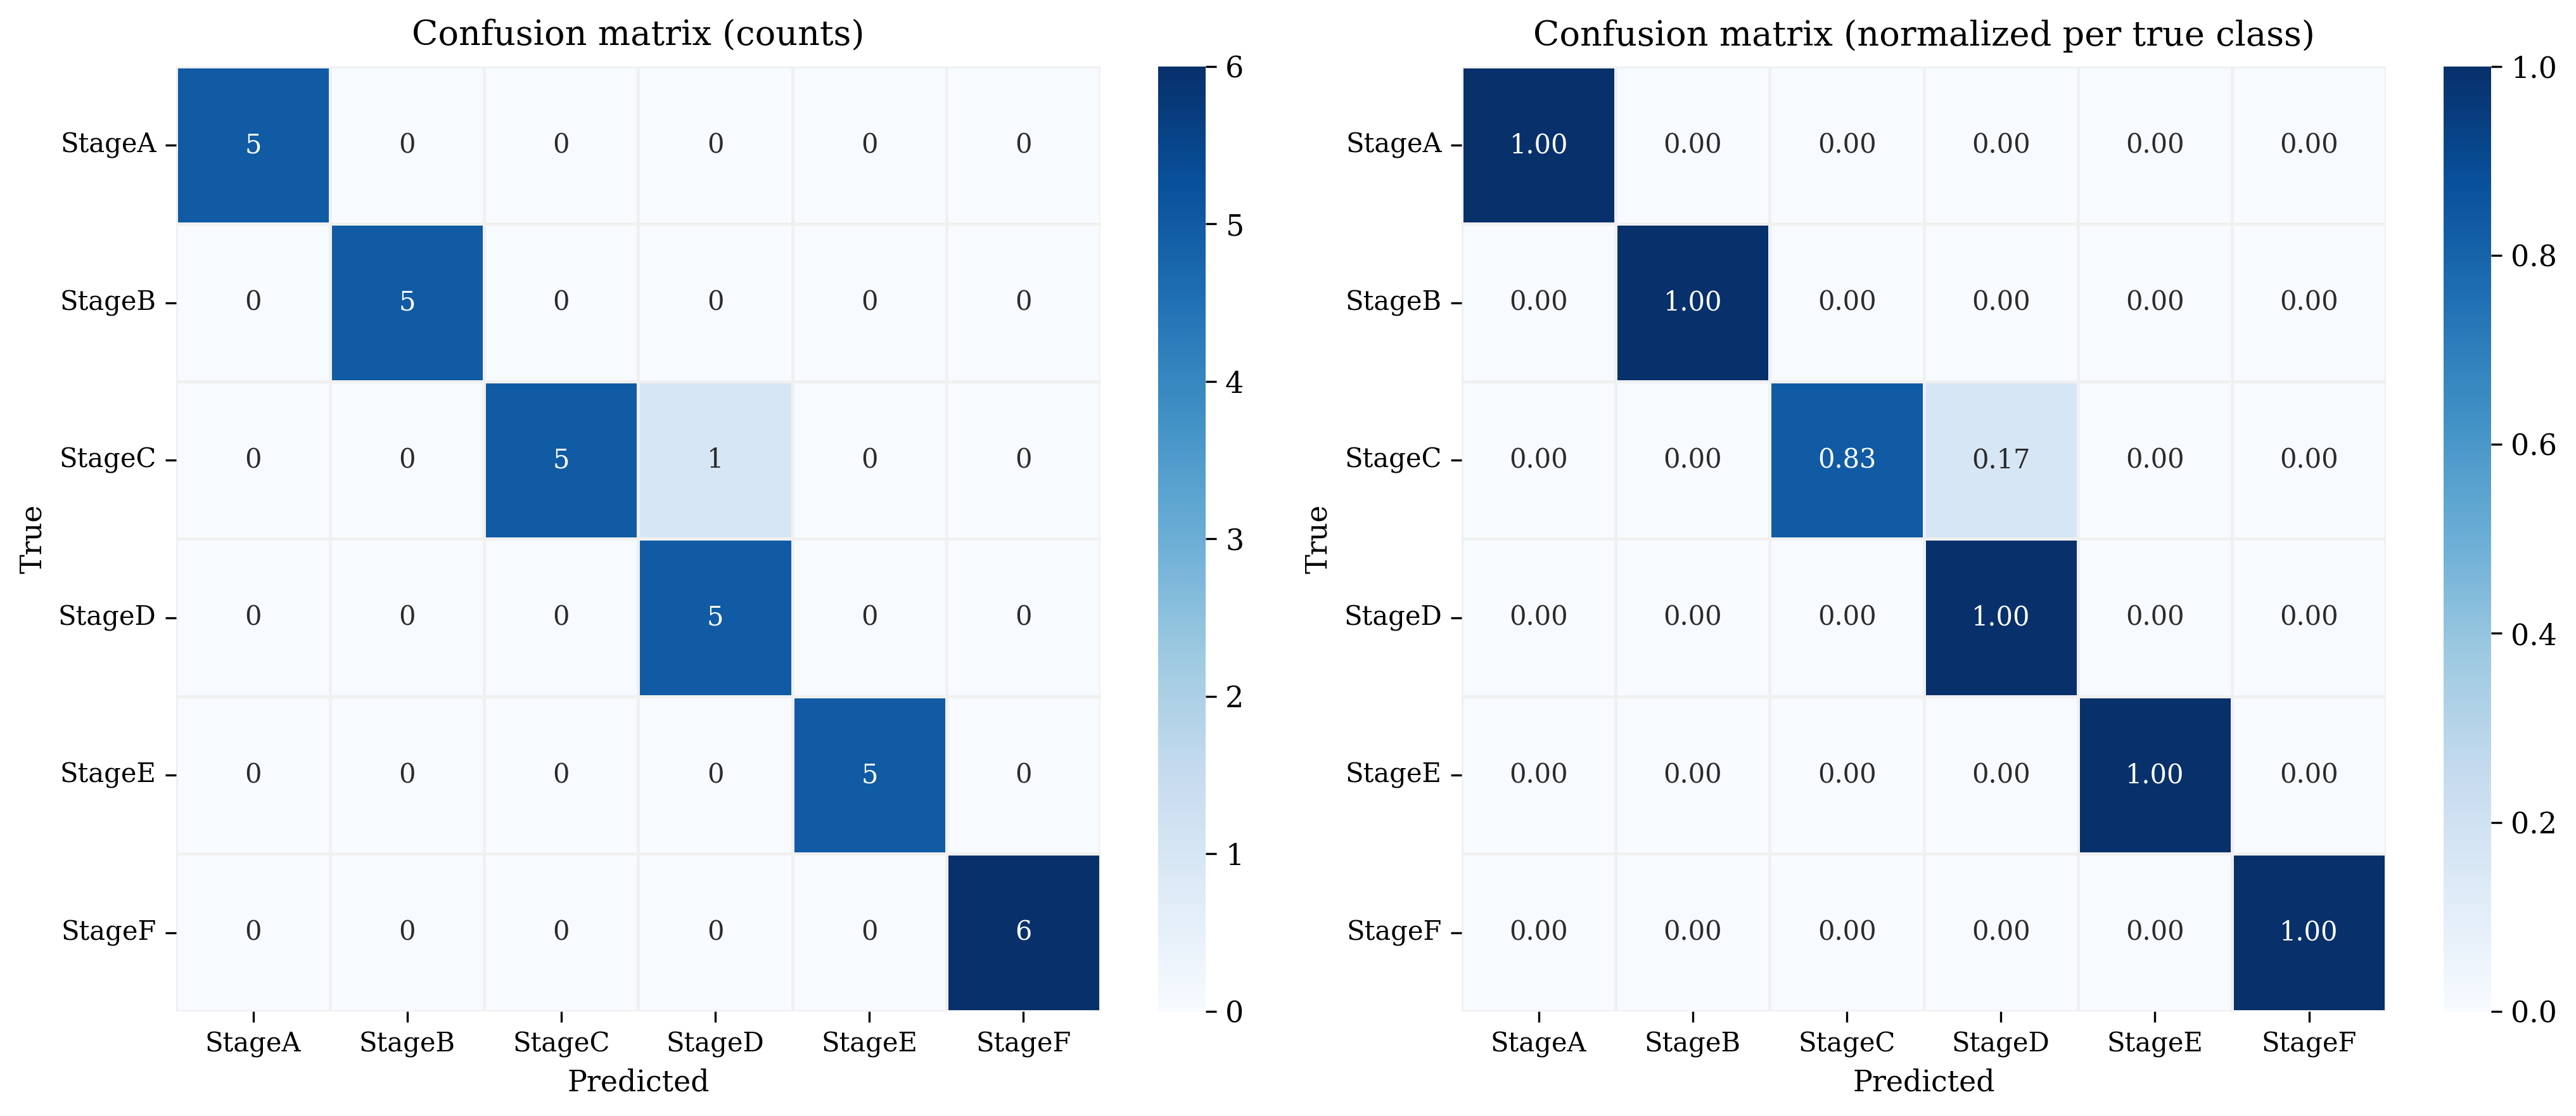

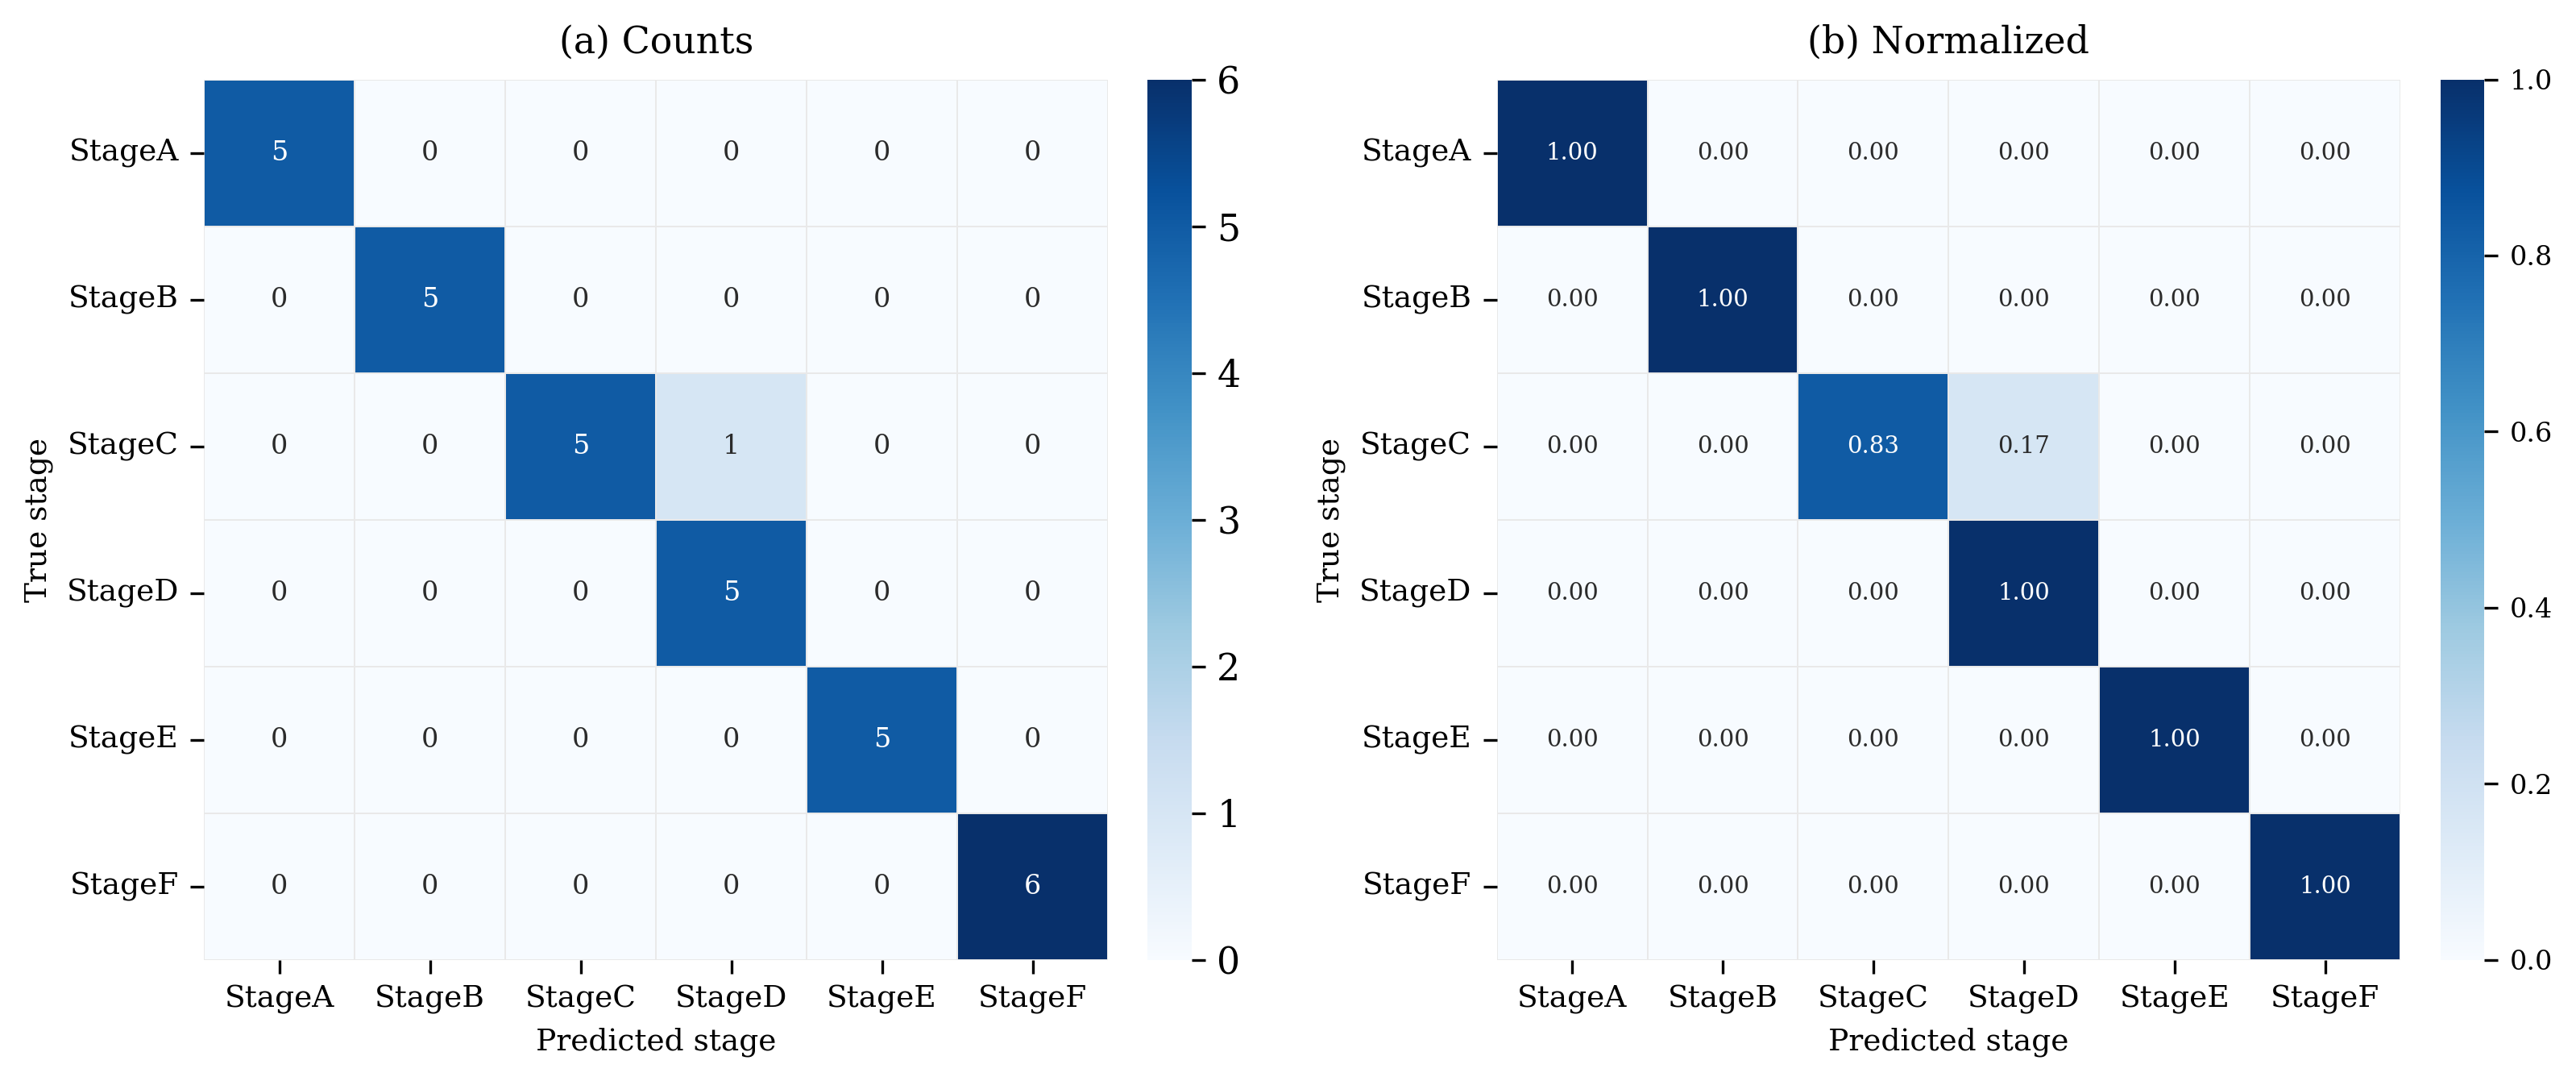

In [127]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================================================
# INPUT
# =========================================================
# y_val        : true validation labels
# y_val_pred   : predicted validation labels
# class_names  : e.g. ["A", "B", "C", "D", "E", "F"]

cm = confusion_matrix(y_val, y_val_pred, labels=class_names)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-12)

# =========================================================
# HELPER FUNCTIONS
# =========================================================
def _annot_color(value, vmax):
    return "white" if value > 0.55 * vmax else "#2b2b2b"

def _draw_heatmap(ax, data, labels, title, fmt, cmap,
                  xlabel="Predicted stage", ylabel="True stage",
                  annot_size=11, title_size=12, label_size=11,
                  tick_size=10, cbar=True, cbar_kws=None,
                  linewidths=0.8, linecolor="#f0f0f0",
                  vmin=None, vmax=None):
    
    hm = sns.heatmap(
        data,
        ax=ax,
        annot=False,   # manual annotation
        fmt=fmt,
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels,
        cbar=cbar,
        cbar_kws=cbar_kws,
        linewidths=linewidths,
        linecolor=linecolor,
        vmin=vmin,
        vmax=vmax,
        square=False
    )

    ax.set_title(title, fontsize=title_size, pad=8)
    ax.set_xlabel(xlabel, fontsize=label_size)
    ax.set_ylabel(ylabel, fontsize=label_size)
    ax.tick_params(axis="x", labelrotation=0, labelsize=tick_size)
    ax.tick_params(axis="y", labelrotation=0, labelsize=tick_size)

    vmax_eff = np.max(data) if vmax is None else vmax

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            text = f"{int(val)}" if fmt == "d" else f"{val:.2f}"
            ax.text(
                j + 0.5, i + 0.5, text,
                ha="center", va="center",
                fontsize=annot_size,
                color=_annot_color(val, vmax_eff)
            )

    return hm

# =========================================================
# 1. STANDARD FORMAT
# =========================================================
def plot_confusion_matrix_validation_standard(cm, cm_norm, class_names,
                                              save_path="confusion_matrix_validation_standard.png"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

    _draw_heatmap(
        ax=axes[0],
        data=cm,
        labels=class_names,
        title="Confusion matrix (counts)",
        fmt="d",
        cmap="Blues",
        xlabel="Predicted",
        ylabel="True",
        annot_size=10,
        title_size=13,
        label_size=11,
        tick_size=10,
        cbar=True
    )

    _draw_heatmap(
        ax=axes[1],
        data=cm_norm,
        labels=class_names,
        title="Confusion matrix (normalized per true class)",
        fmt=".2f",
        cmap="Blues",
        xlabel="Predicted",
        ylabel="True",
        annot_size=10,
        title_size=13,
        label_size=11,
        tick_size=10,
        cbar=True,
        vmin=0.0,
        vmax=1.0
    )

    plt.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

# =========================================================
# 2. MANUSCRIPT FORMAT
# =========================================================
def plot_confusion_matrix_validation_manuscript(cm, cm_norm, class_names,
                                                save_path="confusion_matrix_validation_manuscript.png"):
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11
    })

    fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.6), dpi=300)
    fig.patch.set_facecolor("white")

    # (a) Counts
    _draw_heatmap(
        ax=axes[0],
        data=cm,
        labels=class_names,
        title="(a) Counts",
        fmt="d",
        cmap="Blues",
        xlabel="Predicted stage",
        ylabel="True stage",
        annot_size=8,
        title_size=11,
        label_size=9,
        tick_size=9,
        cbar=True,
        cbar_kws={"fraction": 0.050, "pad": 0.04},
        linewidths=0.4,
        linecolor="#e9e9e9"
    )

    # (b) Normalized
    hm = _draw_heatmap(
        ax=axes[1],
        data=cm_norm,
        labels=class_names,
        title="(b) Normalized",
        fmt=".2f",
        cmap="Blues",
        xlabel="Predicted stage",
        ylabel="True stage",
        annot_size=7,
        title_size=11,
        label_size=9,
        tick_size=9,
        cbar=True,
        cbar_kws={"fraction": 0.050, "pad": 0.04},
        vmin=0.0,
        vmax=1.0,
        linewidths=0.4,
        linecolor="#e9e9e9"
    )

    if hm.collections and len(hm.collections) > 0:
        cbar = hm.collections[0].colorbar
        cbar.ax.tick_params(labelsize=8)

    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout(w_pad=2.0)
    fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

# =========================================================
# RUN BOTH FORMATS
# =========================================================
plot_confusion_matrix_validation_standard(
    cm, cm_norm, class_names,
    save_path="confusion_matrix_validation_standard.png"
)

plot_confusion_matrix_validation_manuscript(
    cm, cm_norm, class_names,
    save_path="confusion_matrix_validation_manuscript.png"
)

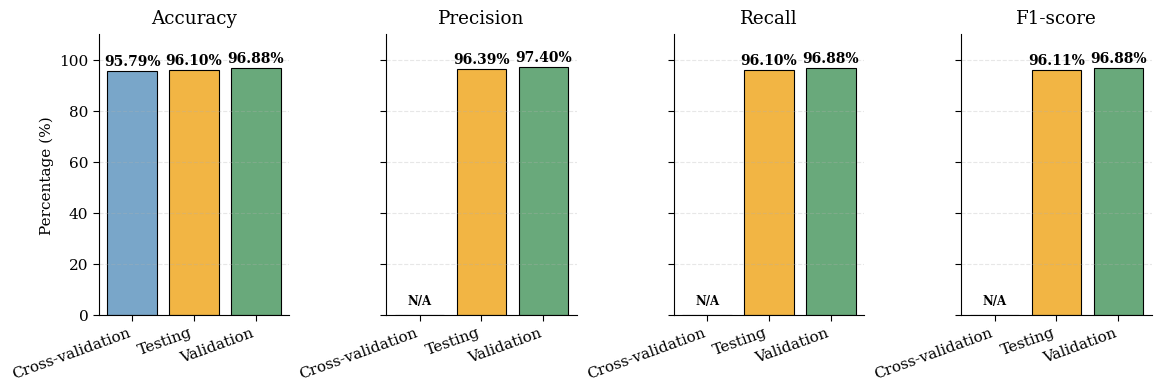

Figure saved as: figure6_metrics_comparison.png


In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Common journal style
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

# =========================
# Updated metrics from new results
# =========================
metrics_summary = pd.DataFrame({
    'Dataset':   ['Cross-validation', 'Testing', 'Validation'],
    'Accuracy':  [95.79, 96.10, 96.88],
    'Precision': [np.nan, 96.39, 97.40],
    'Recall':    [np.nan, 96.10, 96.88],
    'F1-score':  [np.nan, 96.11, 96.88]
})

plot_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
colors = ['#79A6C9', '#F2B544', '#69A97B']  # CV, Testing, Validation

# =========================
# Create figure
# =========================
fig, axes = plt.subplots(1, 4, figsize=(11.5, 3.8), sharey=True, constrained_layout=True)

for ax, metric in zip(axes, plot_metrics):
    values = metrics_summary[metric].values
    x_labels = metrics_summary['Dataset'].values
    x = np.arange(len(x_labels))

    bars = []
    for i, value in enumerate(values):
        if np.isnan(value):
            # draw empty bar outline for N/A
            bar = ax.bar(
                x[i], 0,
                color='white',
                edgecolor='black',
                linewidth=0.8,
                hatch='//'
            )
            ax.text(
                x[i], 3.0, 'N/A',
                ha='center', va='bottom',
                fontsize=8.5, fontweight='bold'
            )
            bars.append(bar)
        else:
            bar = ax.bar(
                x[i], value,
                color=colors[i],
                edgecolor='black',
                linewidth=0.8
            )
            ax.text(
                x[i], value + 1.0,
                f'{value:.2f}%',
                ha='center', va='bottom',
                fontsize=10, fontweight='bold'
            )
            bars.append(bar)

    ax.set_title(metric, pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=20, ha='right')
    ax.set_ylim(0, 110)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Percentage (%)')

# Save figure
output_file = "figure6_metrics_comparison.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved as: {output_file}")